In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np

import pickle
import os
import matplotlib.pyplot as plt
import librosa

In [2]:
from DeepLearning_ICBHI.Step_4_Train_classifier_crackle_narrow import evaluate_saved_model

evaluate_saved_model()


Using device: cpu
✓ Model loaded from epoch 17
DETAILED TEST SET PERFORMANCE (threshold=0.5)

Classification Report:
              precision    recall  f1-score   support

  No Crackle      0.742     0.760     0.751       317
     Crackle      0.519     0.494     0.506       166

    accuracy                          0.669       483
   macro avg      0.630     0.627     0.628       483
weighted avg      0.665     0.669     0.667       483


Confusion Matrix:
  [[TN=241  FP=76]
   [FN=84  TP=82]]

Prediction Distribution:
  Predicted 'No Crackle': 325 (67.3%)
  Predicted 'Crackle':    158 (32.7%)

Actual Distribution:
  Actually 'No Crackle': 317 (65.6%)
  Actually 'Crackle':    166 (34.4%)

THRESHOLD ANALYSIS
  0.25: F1=0.569, Recall=0.735, Precision=0.464, Pred%=54.5%
  0.30: F1=0.552, Recall=0.675, Precision=0.467, Pred%=49.7%
  0.35: F1=0.557, Recall=0.645, Precision=0.491, Pred%=45.1%
  0.40: F1=0.543, Recall=0.584, Precision=0.508, Pred%=39.5%
  0.45: F1=0.534, Recall=0.548, Preci

In [2]:
bestmodel_path_wheeze = 'Databases/ICBHI/traintest_pk/Record/best_model.pth'


In [7]:
from DeepLearning_ICBHI.Step_4_Train_classifier_wheeze_wide import RespiratoryDataset, RespiratoryModel
from DeepLearning_ICBHI import Config

In [ ]:
def validate(model, val_loader, criterion, device):
    """
    Validate the model
    """
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # Don't compute gradients during validation
        for (spec_wide, features), labels in val_loader:
            spec_wide = spec_wide.to(device)
            features = features.to(device)
            labels = labels.to(device).squeeze()
            
            # Forward pass
            outputs = model(spec_wide, features)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

In [47]:
# load wav file
# extract 2s long clips, overlap 1s
# follow preprocessing steps (filter and pad)

from DeepLearning_ICBHI.Step_1_Preprocessing import rawFilter, padding
from DeepLearning_ICBHI.Step_2_Feature_extraction import create_mel_spectrogram, dc_normalise, extract_respiratory_features

dataFolder = "Samples"

data_files = sorted(os.listdir(dataFolder))
#data_files = ['Eko_p000_t02_healthy_20250228.wav']
#data_files = ['Eko_p002_t01_severe_20250221.wav']
#data_files = ['Eko_p003_t01_moderate_20250227.wav']

for data_file in data_files:

    #if not a wav file, skip
    if ".wav" not in data_file:
        continue

    print(data_file)

    # path
    wavFilepath = f"{dataFolder}/{data_file}"

    # load data
    raw_audio, sample_rate = librosa.load(path=wavFilepath, sr=4000)

    clipLength = 2 
    step = 1

    

    audio_data = []

    startWindow = 0
    endWindow = clipLength * sample_rate

    while startWindow + (clipLength * sample_rate) < len(raw_audio):
        clip = raw_audio[startWindow:endWindow]
        clip = rawFilter(clip, sample_rate, Config.filter_order,
                                     Config.filter_lowcut, Config.filter_highcut, btype=Config.filter_btype)
        clip = padding(clip, sample_rate, Config.respiratory_cycle, Config.padding_mode)


        audio_data.append(clip)

        startWindow += int(step*sample_rate)
        endWindow = int(startWindow + clipLength * sample_rate)

   

    samples = []

    for segment in audio_data:
        # removing DC component and normalising to -1/1 window
        data = dc_normalise(segment)

        # Mel spectrograms
        mel_spectrogram_narrow = create_mel_spectrogram(
            data, Config.sample_rate, 
            n_mels=Config.n_mels_narrow,
            f_min=Config.f_min, f_max=Config.f_max, 
            winLength=Config.winLength_narrow,
            nfft=Config.nfft_narrow, 
            hop=Config.hop_narrow
        )

        mel_spectrogram_wide = create_mel_spectrogram(
            data, Config.sample_rate, 
            n_mels=Config.n_mels_wide,
            f_min=Config.f_min, f_max=Config.f_max, 
            winLength=Config.winLength_wide,
            nfft=Config.nfft_wide, 
            hop=Config.hop_wide
        )

        # Acoustic features
        acoustic_features, acoustic_feature_names = extract_respiratory_features(
            data, Config.sample_rate,
            short_window=Config.winLength_narrow,
            long_window=Config.winLength_wide
        )

        # Store everything
        sample = {}
        sample["statistics_feature"] = acoustic_features
        sample["statistics_feature_names"] = acoustic_feature_names
        sample["mel_spectrogram_narrow"] = mel_spectrogram_narrow
        sample["mel_spectrogram_wide"] = mel_spectrogram_wide

        samples.append(sample)
    


    device = "cpu"

    # Initialize model
    model = RespiratoryModel(
        n_mels_wide=Config.n_mels_wide,
        n_features=42,
        num_classes=2
    ).to(device)

    # Load saved weights
    checkpoint_path = bestmodel_path_wheeze
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # print(f"✓ Model loaded from epoch {checkpoint['epoch']}")
    # print(f"  Val Accuracy: {checkpoint['val_accuracy']:.2f}%\n")

    # Get predictions
    all_preds = []
    all_labels = []

    print(f'Len(samples): {len(samples)}')
    for sample in samples:
        
        with torch.no_grad():
            
            spec_wide = sample['mel_spectrogram_wide']
            features = sample['statistics_feature']

            # Check the shape of your spectrogram
            # print(f"Original spec_wide shape: {spec_wide.shape}")
            
            # If spec_wide is (n_mels, 1, time) or (n_mels, time), we need to fix it
            if len(spec_wide.shape) == 2:  # (n_mels, time)
                spec_wide = spec_wide[np.newaxis, ...]  # Add batch dim: (1, n_mels, time)
            elif len(spec_wide.shape) == 3 and spec_wide.shape[1] == 1:  # (n_mels, 1, time)
                spec_wide = np.squeeze(spec_wide, axis=1)  # Remove middle dim: (n_mels, time)
                spec_wide = spec_wide[np.newaxis, ...]  # Add batch dim: (1, n_mels, time)
            
            # Similarly for features - add batch dimension if needed
            if len(features.shape) == 1:  # (n_features,)
                features = features[np.newaxis, ...]  # (1, n_features)
            
            # print(f"Fixed spec_wide shape: {spec_wide.shape}")
            # print(f"Features shape: {features.shape}")

            spec_wide = torch.FloatTensor(spec_wide)
            features = torch.FloatTensor(features)
            
            spec_wide = spec_wide.to(device)
            features = features.to(device)

            outputs = model(spec_wide, features)
            _, preds = torch.max(outputs, 1)
        
            all_preds.append(int(preds))
        
    print(all_preds)
    

Eko_p001_t01_mild_20250214.wav
Len(samples): 13
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Eko_p002_t01_severe_20250221.wav
Len(samples): 13
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Eko_p002_t02_severe_20250221.wav
Len(samples): 13
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Eko_p003_t01_moderate_20250227.wav
Len(samples): 13
[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Eko_p003_t02_moderate_20250227.wav
Len(samples): 58
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Eko_p004_t01_moderate_20250228.wav
Len(samples): 58
[1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0]
Eko_p004_t02_moderate_20250228.wav
Len(samples): 58
[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0

In [46]:
int(preds)

0

In [ ]:
from DeepLearning_ICBHI.Step_2_Feature_extraction import create_mel_spectrogram, dc_normalise, extract_respiratory_features

samples = []

for segment in audio_data:
    # removing DC component and normalising to -1/1 window
    data = dc_normalise(segment)

    # Mel spectrograms
    mel_spectrogram_narrow = create_mel_spectrogram(
        data, Config.sample_rate, 
        n_mels=Config.n_mels_narrow,
        f_min=Config.f_min, f_max=Config.f_max, 
        winLength=Config.winLength_narrow,
        nfft=Config.nfft_narrow, 
        hop=Config.hop_narrow
    )

    mel_spectrogram_wide = create_mel_spectrogram(
        data, Config.sample_rate, 
        n_mels=Config.n_mels_wide,
        f_min=Config.f_min, f_max=Config.f_max, 
        winLength=Config.winLength_wide,
        nfft=Config.nfft_wide, 
        hop=Config.hop_wide
    )

    # Acoustic features
    acoustic_features, acoustic_feature_names = extract_respiratory_features(
        data, Config.sample_rate,
        short_window=Config.winLength_narrow,
        long_window=Config.winLength_wide
    )

    # Store everything
    sample = {}
    sample["statistics_feature"] = acoustic_features
    sample["statistics_feature_names"] = acoustic_feature_names
    sample["mel_spectrogram_narrow"] = mel_spectrogram_narrow
    sample["mel_spectrogram_wide"] = mel_spectrogram_wide

    samples.append(sample)

    device = "cpu"

# Initialize model
model = RespiratoryModel(
    n_mels_wide=Config.n_mels_wide,
    n_features=42,
    num_classes=2
).to(device)

# Load saved weights
checkpoint_path = bestmodel_path_wheeze
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Model loaded from epoch {checkpoint['epoch']}")
print(f"  Val Accuracy: {checkpoint['val_accuracy']:.2f}%\n")

# Get predictions
all_preds = []
all_labels = []


for sample in samples:
    with torch.no_grad():
        
        spec_wide = sample['mel_spectrogram_wide']
        features = sample['statistics_feature']

        # Check the shape of your spectrogram
        print(f"Original spec_wide shape: {spec_wide.shape}")
        
        # If spec_wide is (n_mels, 1, time) or (n_mels, time), we need to fix it
        if len(spec_wide.shape) == 2:  # (n_mels, time)
            spec_wide = spec_wide[np.newaxis, ...]  # Add batch dim: (1, n_mels, time)
        elif len(spec_wide.shape) == 3 and spec_wide.shape[1] == 1:  # (n_mels, 1, time)
            spec_wide = np.squeeze(spec_wide, axis=1)  # Remove middle dim: (n_mels, time)
            spec_wide = spec_wide[np.newaxis, ...]  # Add batch dim: (1, n_mels, time)
        
        # Similarly for features - add batch dimension if needed
        if len(features.shape) == 1:  # (n_features,)
            features = features[np.newaxis, ...]  # (1, n_features)
        
        print(f"Fixed spec_wide shape: {spec_wide.shape}")
        print(f"Features shape: {features.shape}")

        spec_wide = torch.FloatTensor(spec_wide)
        features = torch.FloatTensor(features)
        
        spec_wide = spec_wide.to(device)
        features = features.to(device)

        outputs = model(spec_wide, features)
        _, preds = torch.max(outputs, 1)
    
        all_preds.append(preds)
    
    print(all_preds)

In [ ]:
device = "cpu"

# Initialize model
model = RespiratoryModel(
    n_mels_wide=Config.n_mels_wide,
    n_features=42,
    num_classes=2
).to(device)

# Load saved weights
checkpoint_path = bestmodel_path_wheeze
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Model loaded from epoch {checkpoint['epoch']}")
print(f"  Val Accuracy: {checkpoint['val_accuracy']:.2f}%\n")

# Get predictions
all_preds = []
all_labels = []


for sample in samples:
    with torch.no_grad():
        
        spec_wide = sample['mel_spectrogram_wide']
        features = sample['statistics_feature']

        # Check the shape of your spectrogram
        print(f"Original spec_wide shape: {spec_wide.shape}")
        
        # If spec_wide is (n_mels, 1, time) or (n_mels, time), we need to fix it
        if len(spec_wide.shape) == 2:  # (n_mels, time)
            spec_wide = spec_wide[np.newaxis, ...]  # Add batch dim: (1, n_mels, time)
        elif len(spec_wide.shape) == 3 and spec_wide.shape[1] == 1:  # (n_mels, 1, time)
            spec_wide = np.squeeze(spec_wide, axis=1)  # Remove middle dim: (n_mels, time)
            spec_wide = spec_wide[np.newaxis, ...]  # Add batch dim: (1, n_mels, time)
        
        # Similarly for features - add batch dimension if needed
        if len(features.shape) == 1:  # (n_features,)
            features = features[np.newaxis, ...]  # (1, n_features)
        
        print(f"Fixed spec_wide shape: {spec_wide.shape}")
        print(f"Features shape: {features.shape}")

        spec_wide = torch.FloatTensor(spec_wide)
        features = torch.FloatTensor(features)
        
        spec_wide = spec_wide.to(device)
        features = features.to(device)

        outputs = model(spec_wide, features)
        _, preds = torch.max(outputs, 1)
    
        all_preds.append(preds)

    print(all_preds)

✓ Model loaded from epoch 11
  Val Accuracy: 87.37%

Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features shape: (1, 42)
Original spec_wide shape: (48, 153)
Fixed spec_wide shape: (1, 48, 153)
Features sh

In [33]:
all_preds

[tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([1]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0])]

In [6]:
datFilePath = 'Databases/ICBHI/Preprocessing'

datFile = '101_1B1_Al_sc_Meditron_0.dat'

fullPath = os.path.join(datFilePath,datFile)

with open(fullPath,'rb') as f:
    sample = pickle.load(f,encoding='latin1')


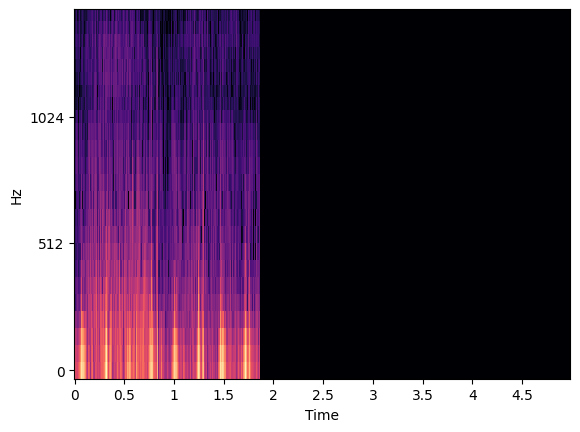

In [20]:
import librosa
fig,ax = plt.subplots()

img = librosa.display.specshow(sample['mel_spectrogram_narrow'], x_axis='time',
                                       y_axis='mel', sr=4000, hop_length = 16,
                                       fmax=1800, ax=ax)


In [31]:
#checking breakdown of raw files (location of recording, equipment etc)

rawFolder = 'Databases/ICBHI/audio_and_txt_files'

allWavFiles = sorted([f for f in os.listdir(rawFolder) if f.endswith('.wav')])

In [32]:
import pandas as pd
splitData = pd.DataFrame(allWavFiles,columns=['FullFile'])


In [33]:
splitData['Patient'] = splitData['FullFile'].apply(lambda x: x.split('_')[0])
splitData['Test'] = splitData['FullFile'].apply(lambda x: x.split('_')[1])
splitData['Location'] = splitData['FullFile'].apply(lambda x: x.split('_')[2])
splitData['SingleMulti'] = splitData['FullFile'].apply(lambda x: x.split('_')[3])
splitData['Device'] = splitData['FullFile'].apply(lambda x: x.split('_')[4])

In [34]:
splitData['Location'].value_counts()

Location
Ar    168
Al    162
Pl    139
Pr    132
Tc    130
Lr    112
Ll     77
Name: count, dtype: int64

In [35]:
splitData['SingleMulti'].value_counts()

SingleMulti
mc    732
sc    188
Name: count, dtype: int64

In [36]:
splitData[(splitData['Location']=='Pr') | (splitData['Location']=='Pl')]['SingleMulti'].value_counts()

SingleMulti
mc    220
sc     51
Name: count, dtype: int64

In [37]:
splitData.iloc[:30]

,FullFile,Patient,Test,Location,SingleMulti,Device
0,101_1b1_Al_sc_Meditron.wav,101,1b1,Al,sc,Meditron.wav
1,101_1b1_Pr_sc_Meditron.wav,101,1b1,Pr,sc,Meditron.wav
2,102_1b1_Ar_sc_Meditron.wav,102,1b1,Ar,sc,Meditron.wav
3,103_2b2_Ar_mc_LittC2SE.wav,103,2b2,Ar,mc,LittC2SE.wav
4,104_1b1_Al_sc_Litt3200.wav,104,1b1,Al,sc,Litt3200.wav
5,104_1b1_Ar_sc_Litt3200.wav,104,1b1,Ar,sc,Litt3200.wav
6,104_1b1_Ll_sc_Litt3200.wav,104,1b1,Ll,sc,Litt3200.wav
7,104_1b1_Lr_sc_Litt3200.wav,104,1b1,Lr,sc,Litt3200.wav
8,104_1b1_Pl_sc_Litt3200.wav,104,1b1,Pl,sc,Litt3200.wav
9,104_1b1_Pr_sc_Litt3200.wav,104,1b1,Pr,sc,Litt3200.wav


In [ ]:
# Extracting features from PF dataset

from DeepLearning_ICBHI.Step_2_Feature_extraction import extract_respiratory_features




NameError: name 'data' is not defined

In [53]:
import wav_utils

dataFolder = "Samples"

data_files = sorted(os.listdir(dataFolder))
#data_files = ['Eko_p000_t02_healthy_20250228.wav']
#data_files = ['Eko_p002_t01_severe_20250221.wav']
#data_files = ['Eko_p003_t01_moderate_20250227.wav']

allFeatures = []

diagnosis_score = {
    'healthy': 0,
    'mild': 1,
    'moderate': 2,
    'severe': 3
}

allScores = []

for data_file in data_files:

    #if not a wav file, skip
    if ".wav" not in data_file:
        continue

    if data_file.startswith('Eko_p008'):
        continue

    print(data_file)
    allScores.append(diagnosis_score[data_file.split('_')[3]])


    # path
    wavFilepath = f"{dataFolder}/{data_file}"

    # load data
    raw_audio, sample_rate = librosa.load(path=wavFilepath, sr=4000)

    # Noise reduction method, filter
    filter_lowcut = 80
    filter_highcut = 1800
    filter_order = 8
    filter_btype = "bandpass"  
    filt_audio = wav_utils.filter_denoise(raw_audio, sample_rate, filter_order,
                                    filter_lowcut, filter_highcut, btype=filter_btype)

    # Normalise and remove DC component in signal
    filt_audio = wav_utils.dc_normalise(filt_audio)  

    acoustic_features, acoustic_feature_names = extract_respiratory_features(
        filt_audio, sample_rate,
        short_window=32,
        long_window=256
    )

    allFeatures.append(acoustic_features)

Eko_p001_t01_mild_20250214.wav
Eko_p002_t01_severe_20250221.wav
Eko_p002_t02_severe_20250221.wav
Eko_p003_t01_moderate_20250227.wav
Eko_p003_t02_moderate_20250227.wav
Eko_p004_t01_moderate_20250228.wav
Eko_p004_t02_moderate_20250228.wav
Eko_p005_t01_healthy_20250228.wav
Eko_p005_t02_healthy_20250228.wav
Eko_p006_t01_severe_20250604.wav
Eko_p007_t01_severe_20250605.wav
Eko_p007_t02_severe_20250605.wav


In [54]:
allFeatures_means = np.mean(allFeatures,axis=0)
allFeatures_std = np.std(allFeatures,axis=0)


In [55]:
allFeatures_norm = allFeatures_means / allFeatures_std

In [43]:
allFeatures_norm

array([ 7.42194113,  6.4017287 ,  1.54370606,  2.30565474,  6.86984605,
        0.68849616, 35.61709007, 21.78503071, 35.71009563, 12.5552929 ,
        5.7779069 , 11.48214842,  6.25413522,  7.78400757,  2.5785226 ,
        2.79339003, -8.83025466,  5.64114225,  8.32874137,  5.70654226,
        4.27625093,  4.94012191, -0.12050859,  7.36204656, -2.83651898,
        6.04181303, -1.16810089, 12.38554356, -4.09304284,  9.88173516,
       -3.10668666, 10.88447273, -3.32745906,  8.51237758, -3.77000912,
        6.93501786, -7.11479289,  8.81039956, -6.50476704,  7.0016281 ,
       -8.27045818,  5.91942985])

In [44]:
allFeatures_norm2 = (allFeatures - allFeatures_means) / allFeatures_std

In [56]:
allFeatures_norm

array([ 7.42194113,  6.4017287 ,  1.54370606,  2.30565474,  6.86984605,
        0.68849616, 35.61709007, 21.78503071, 35.71009563, 12.5552929 ,
        5.7779069 , 11.48214842,  6.25413522,  7.78400757,  2.5785226 ,
        2.79339003, -8.83025466,  5.64114225,  8.32874137,  5.70654226,
        4.27625093,  4.94012191, -0.12050859,  7.36204656, -2.83651898,
        6.04181303, -1.16810089, 12.38554356, -4.09304284,  9.88173516,
       -3.10668666, 10.88447273, -3.32745906,  8.51237758, -3.77000912,
        6.93501786, -7.11479289,  8.81039956, -6.50476704,  7.0016281 ,
       -8.27045818,  5.91942985])

In [46]:
allScores

[1, 3, 3, 2, 2, 2, 2, 0, 0, 3, 3, 3]

In [52]:
for idx in range(len(allFeatures_norm)):


    featureVals = [x[idx] for x in allFeatures_norm]

    plt.scatter(allScores,featureVals)
    plt.suptitle(acoustic_feature_names[idx])
    plt.show()

IndexError: invalid index to scalar variable.

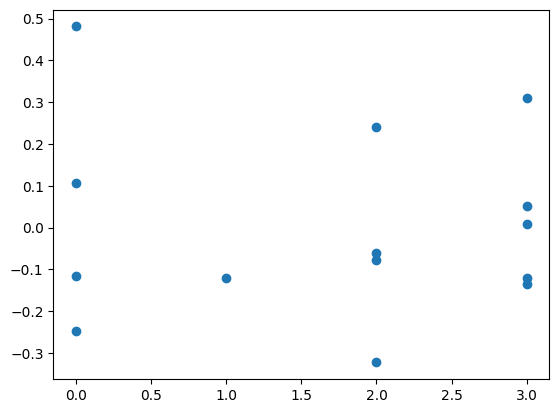

In [37]:
acoustic_feature_names

['short_zcr_mean',
 'short_zcr_std',
 'short_rms_mean',
 'short_rms_std',
 'short_rms_max',
 'short_rms_kurtosis',
 'short_flux_mean',
 'short_flux_std',
 'short_flux_max',
 'long_centroid_mean',
 'long_centroid_std',
 'long_bandwidth_mean',
 'long_bandwidth_std',
 'long_rolloff_mean',
 'long_flatness_mean',
 'long_flatness_std',
 'long_mfcc_1_mean',
 'long_mfcc_1_std',
 'long_mfcc_2_mean',
 'long_mfcc_2_std',
 'long_mfcc_3_mean',
 'long_mfcc_3_std',
 'long_mfcc_4_mean',
 'long_mfcc_4_std',
 'long_mfcc_5_mean',
 'long_mfcc_5_std',
 'long_mfcc_6_mean',
 'long_mfcc_6_std',
 'long_mfcc_7_mean',
 'long_mfcc_7_std',
 'long_mfcc_8_mean',
 'long_mfcc_8_std',
 'long_mfcc_9_mean',
 'long_mfcc_9_std',
 'long_mfcc_10_mean',
 'long_mfcc_10_std',
 'long_mfcc_11_mean',
 'long_mfcc_11_std',
 'long_mfcc_12_mean',
 'long_mfcc_12_std',
 'long_mfcc_13_mean',
 'long_mfcc_13_std']

In [38]:
len(allFeatures_norm)

14

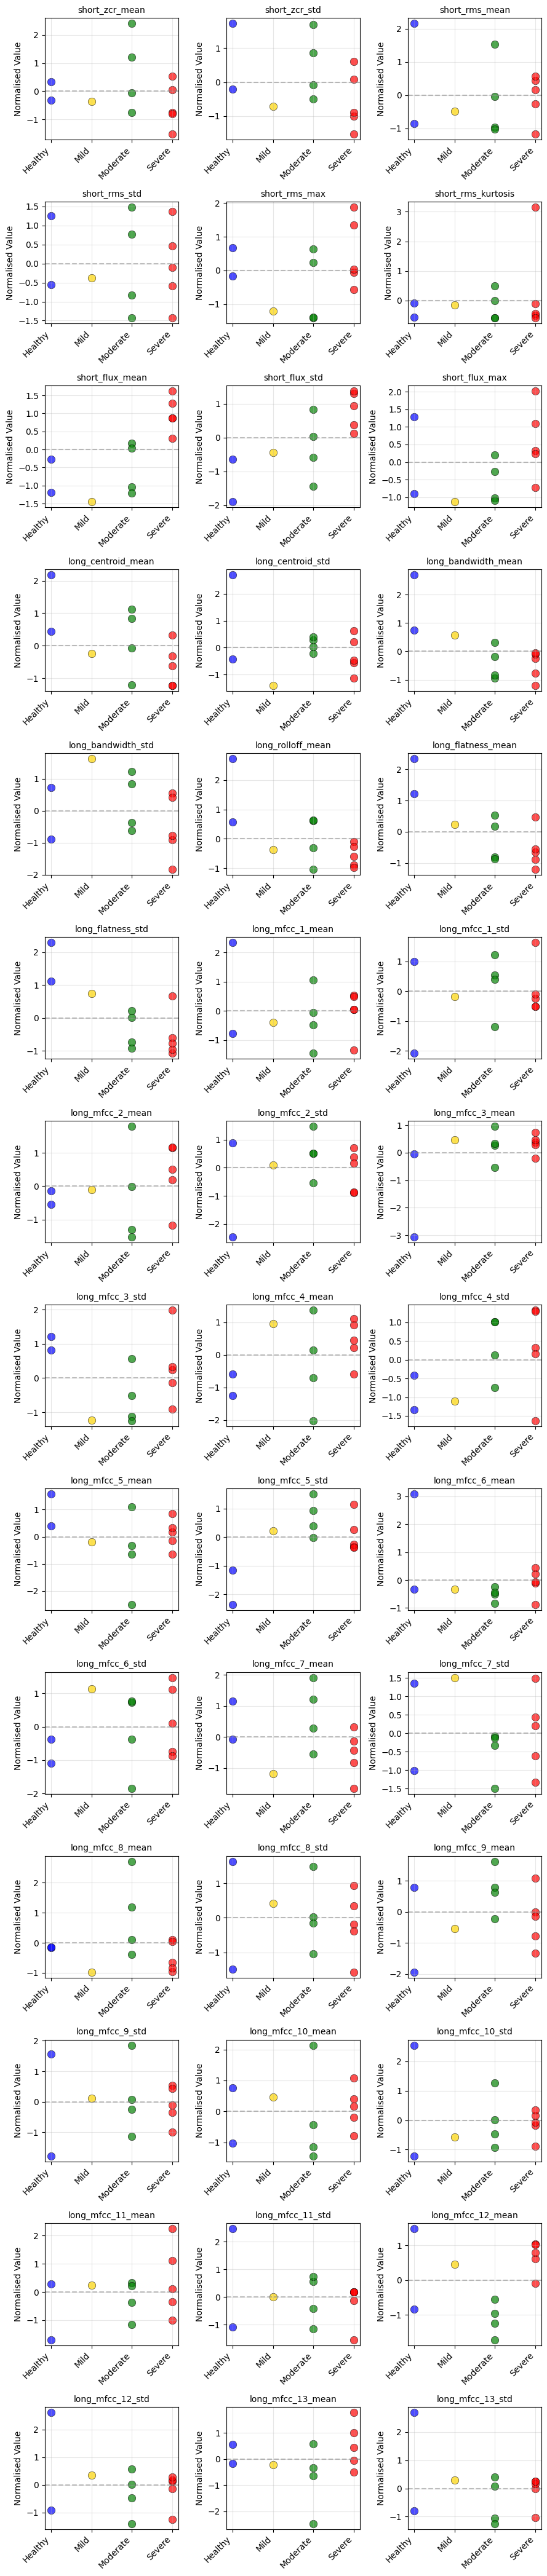

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# After your feature extraction loop, add this:

# Convert to numpy array
allFeatures = np.array(allFeatures)
allScores = np.array(allScores)

# Normalize features (z-score normalization)
scaler = StandardScaler()
normalised_features = scaler.fit_transform(allFeatures)

# Diagnosis labels and colors
diagnosis_labels = ['Healthy', 'Mild', 'Moderate', 'Severe']
diagnosis_colors = {
    0: 'blue',      # Healthy
    1: 'gold',      # Mild
    2: 'green',     # Moderate
    3: 'red'        # Severe
}

# Calculate grid dimensions
n_features = len(acoustic_feature_names)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 3 * n_rows))
axes = axes.flatten()

# Plot each feature
for i, feature_name in enumerate(acoustic_feature_names):
    ax = axes[i]
    
    # Get feature values for each diagnosis
    for score in range(4):
        mask = allScores == score
        if np.any(mask):
            values = normalised_features[mask, i]
            # Add jitter to x position for visibility
            x_positions = np.ones(len(values)) * score
            ax.scatter(x_positions, values, 
                      c=diagnosis_colors[score], 
                      s=80, 
                      alpha=0.7,
                      edgecolors='black',
                      linewidths=0.5)
    
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(diagnosis_labels, rotation=45, ha='right')
    ax.set_ylabel('Normalised Value')
    ax.set_title(feature_name, fontsize=10)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('acoustic_features_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Loading new test record
testFile = 'experiment_crackles_narrow+wide_20260126_114535.pkl'

recordFolder = 'Databases/ICBHI/traintest_CLEANED/Record_Crackles_Narrow_Wide'

from DeepLearning_ICBHI.Step_4_Train_classifier_FULL import load_experiment_results

testResults = load_experiment_results(os.path.join(recordFolder,testFile))

In [8]:
testResults

{'timestamp': '2026-01-26T11:43:37.439482',
 'random_seed': 42,
 'task': 'crackles',
 'use_narrow': True,
 'use_wide': True,
 'class_weights': [1.0, 1.5],
 'dropout_cnn': 0.3,
 'dropout_fusion': 0.0,
 'learning_rate': 0.0001,
 'weight_decay': 0.03,
 'batch_size': 32,
 'augmentation_enabled': False,
 'augmentation_params': None,
 'model_architecture': {'use_narrow': True,
  'use_wide': True,
  'dropout_cnn': 0.3,
  'dropout_fusion': 0.0,
  'parameters': {'total': 305218, 'trainable': 305218}},
 'epochs_trained': 23,
 'best_epoch': 8,
 'total_training_time_seconds': 894.5010509490967,
 'avg_epoch_time_seconds': 38.8198852331742,
 'early_stopping_patience': 15,
 'training_history': {'train_losses': [0.6493570134043694,
   0.5880956016480923,
   0.564989373087883,
   0.5264281835407019,
   0.505808325484395,
   0.5003983788192272,
   0.478465742431581,
   0.45947554241865873,
   0.4561576833948493,
   0.43280134815722704,
   0.4258337374776602,
   0.4124227790161967,
   0.41818281542509794

In [59]:
allResultFiles = [f for f in os.listdir('Databases/ICBHI/traintest_CLEANED/Record_Crackles_Narrow_Wide') if f.endswith('.pkl')]

learning_rate = 0.0001
weight_decay = 0.03

train_f1s = []
val_f1s = []
test_f1s = []
fus_dropouts = []
cnn_dropouts = []

best_val_loss = []


for resultFile in allResultFiles:

    testResults = load_experiment_results(os.path.join(recordFolder,resultFile))

    if testResults['learning_rate'] != learning_rate or testResults['weight_decay'] != weight_decay or testResults['random_seed'] != 456:
        continue


    train_f1s.append(testResults['train_metrics']['f1'])
    val_f1s.append(testResults['val_metrics']['f1'])
    test_f1s.append(testResults['test_metrics']['f1'])
    fus_dropouts.append(testResults['dropout_fusion'])
    cnn_dropouts.append(testResults['dropout_cnn'])

    best_epoch = testResults['best_epoch']
    best_val_loss.append(testResults['training_history']['val_losses'][best_epoch])





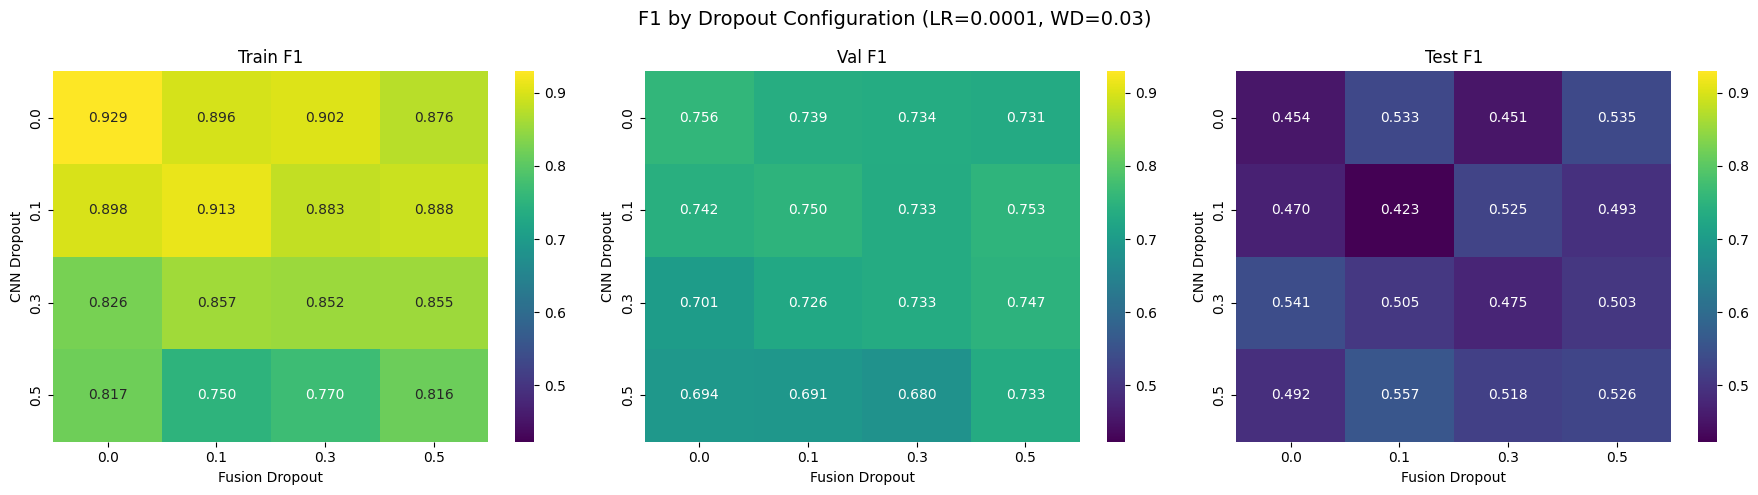

In [60]:
import seaborn as sns
import pandas as pd

# Create dataframe from your results
df = pd.DataFrame({
    'cnn_dropout': cnn_dropouts,
    'fusion_dropout': fus_dropouts,
    'train_f1': train_f1s,
    'val_f1': val_f1s,
    'test_f1': test_f1s
})

# Pivot to create grid (averages if multiple runs per combination)
train_heatmap_data = df.pivot_table(index='cnn_dropout', columns='fusion_dropout', values='train_f1', aggfunc='mean')
val_heatmap_data = df.pivot_table(index='cnn_dropout', columns='fusion_dropout', values='val_f1', aggfunc='mean')
test_heatmap_data = df.pivot_table(index='cnn_dropout', columns='fusion_dropout', values='test_f1', aggfunc='mean')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use same color scale across all three for fair comparison
vmin = min(train_heatmap_data.min().min(), val_heatmap_data.min().min(), test_heatmap_data.min().min())
vmax = max(train_heatmap_data.max().max(), val_heatmap_data.max().max(), test_heatmap_data.max().max())

sns.heatmap(train_heatmap_data, annot=True, fmt='.3f', cmap='viridis', ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title('Train F1')
axes[0].set_xlabel('Fusion Dropout')
axes[0].set_ylabel('CNN Dropout')

sns.heatmap(val_heatmap_data, annot=True, fmt='.3f', cmap='viridis', ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title('Val F1')
axes[1].set_xlabel('Fusion Dropout')
axes[1].set_ylabel('CNN Dropout')

sns.heatmap(test_heatmap_data, annot=True, fmt='.3f', cmap='viridis', ax=axes[2], vmin=vmin, vmax=vmax)
axes[2].set_title('Test F1')
axes[2].set_xlabel('Fusion Dropout')
axes[2].set_ylabel('CNN Dropout')

plt.suptitle(f'F1 by Dropout Configuration (LR={learning_rate}, WD={weight_decay})', fontsize=14)
plt.tight_layout()
plt.show()

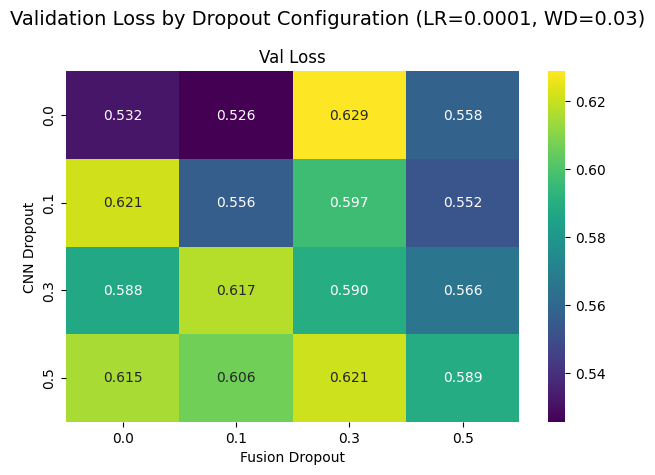

In [61]:
# Create dataframe from your results
df = pd.DataFrame({
    'cnn_dropout': cnn_dropouts,
    'fusion_dropout': fus_dropouts,
    'train_f1': train_f1s,
    'val_f1': val_f1s,
    'test_f1': test_f1s,
    'best_val_loss': best_val_loss
})

# Pivot to create grid (averages if multiple runs per combination)
loss_heatmap_data = df.pivot_table(index='cnn_dropout', columns='fusion_dropout', values='best_val_loss', aggfunc='mean')

fig, ax = plt.subplots()

sns.heatmap(loss_heatmap_data, annot=True, fmt='.3f', cmap='viridis', ax=ax)
ax.set_title('Val Loss')
ax.set_xlabel('Fusion Dropout')
ax.set_ylabel('CNN Dropout')



plt.suptitle(f'Validation Loss by Dropout Configuration (LR={learning_rate}, WD={weight_decay})', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/w5/38gvs5991kl2xwv6ry5ys4mw0000gn/T/ipykernel_1442/719328048.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots()


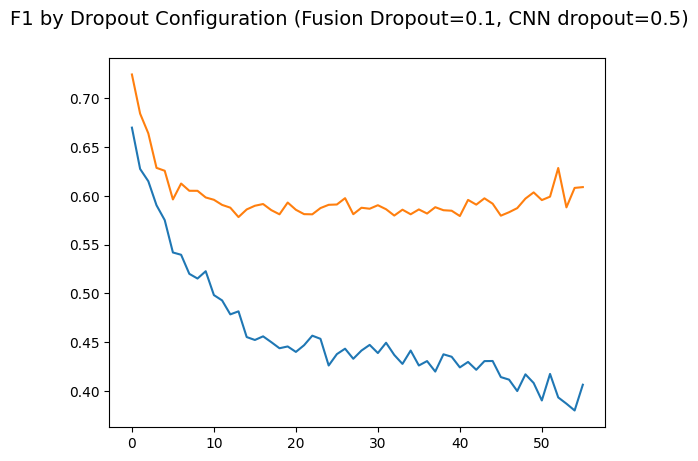

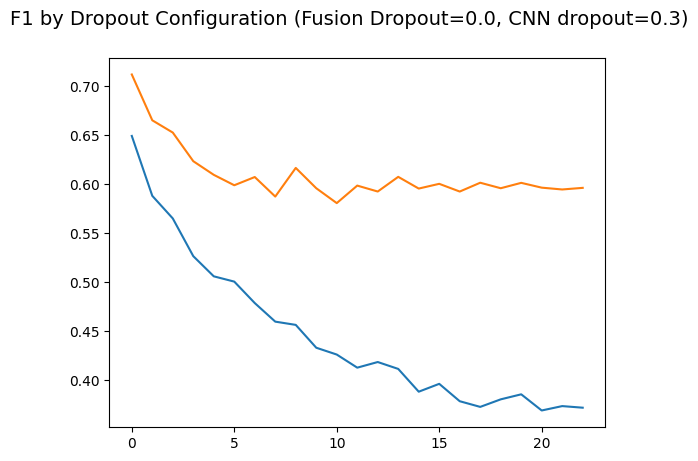

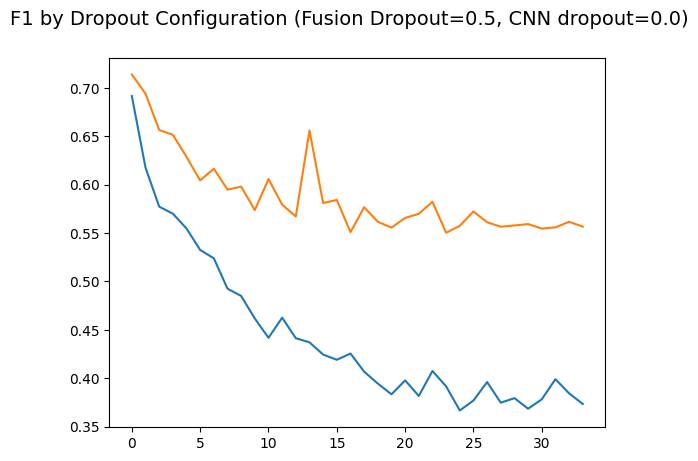

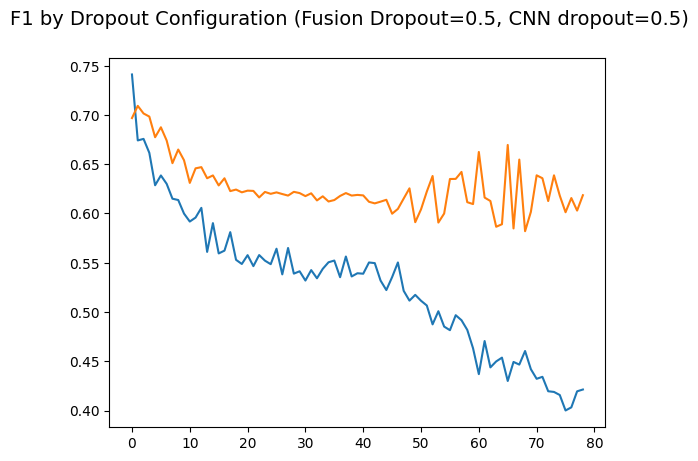

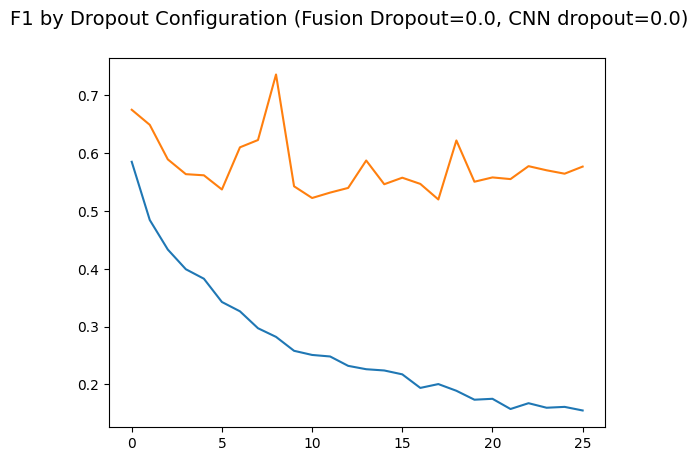

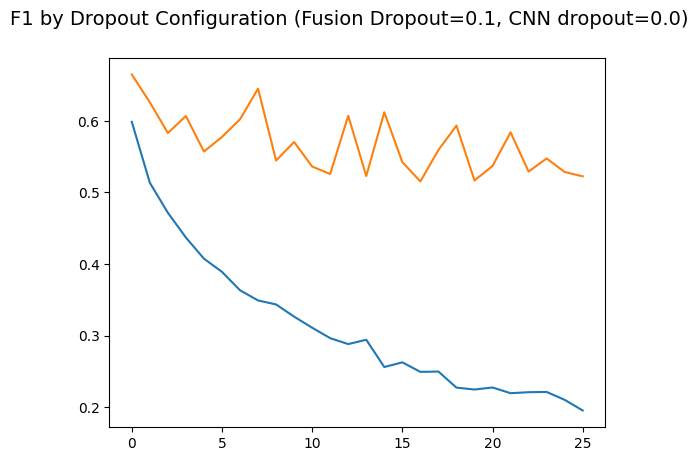

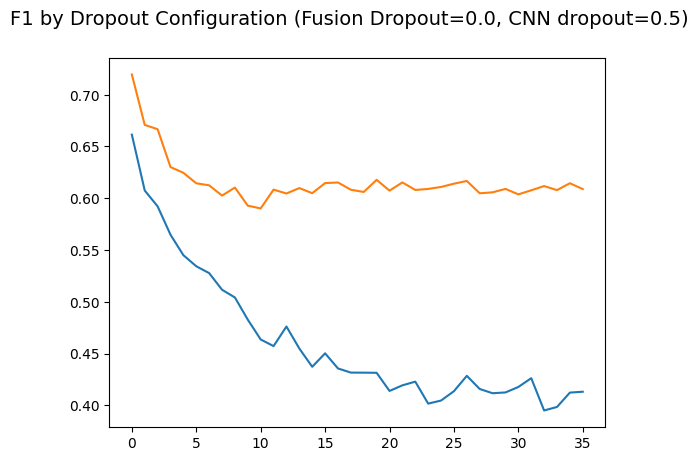

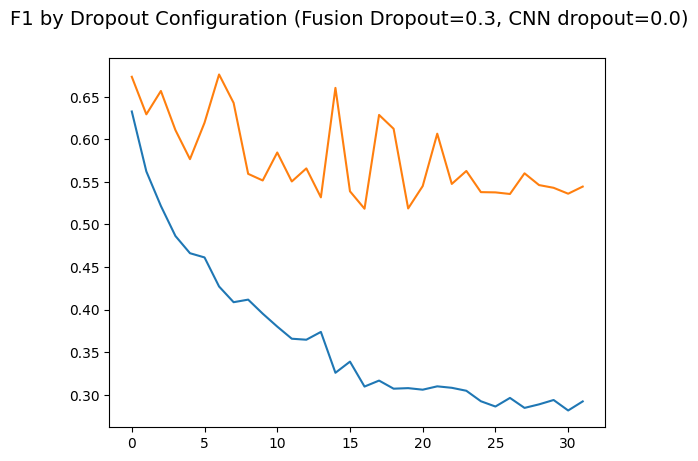

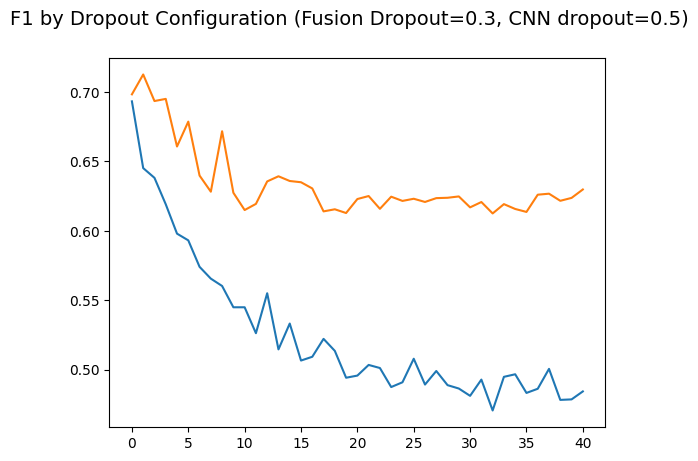

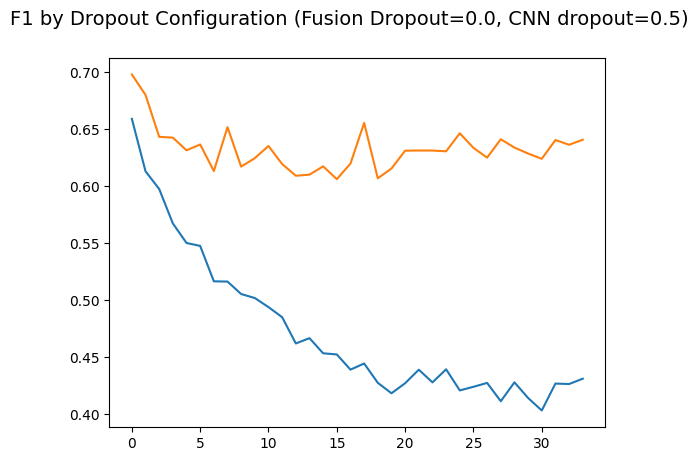

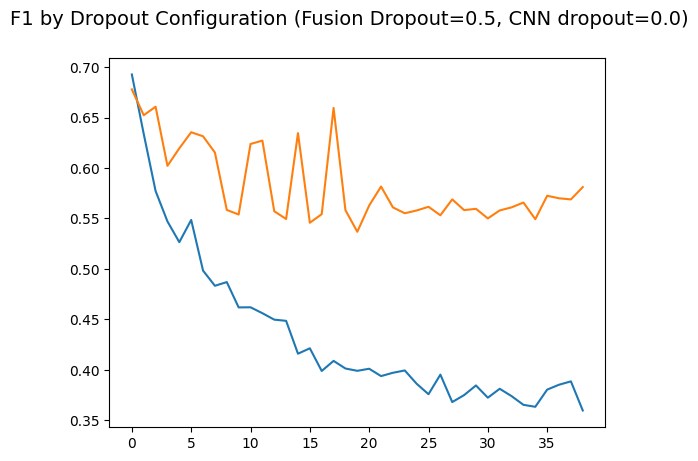

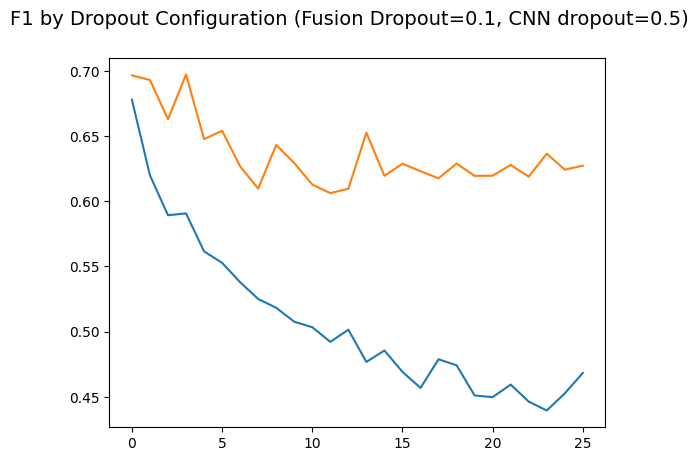

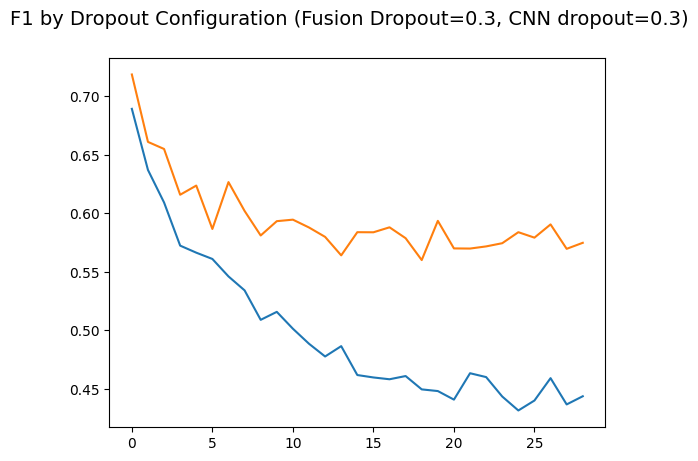

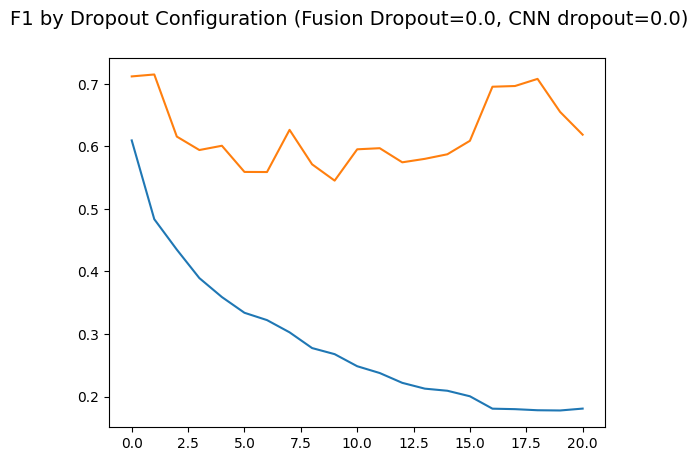

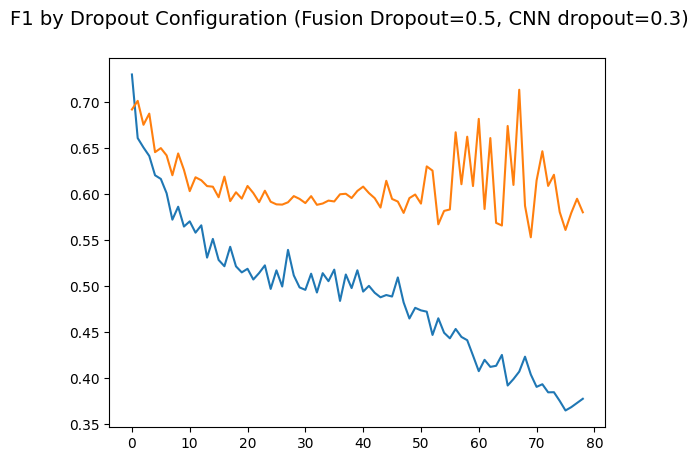

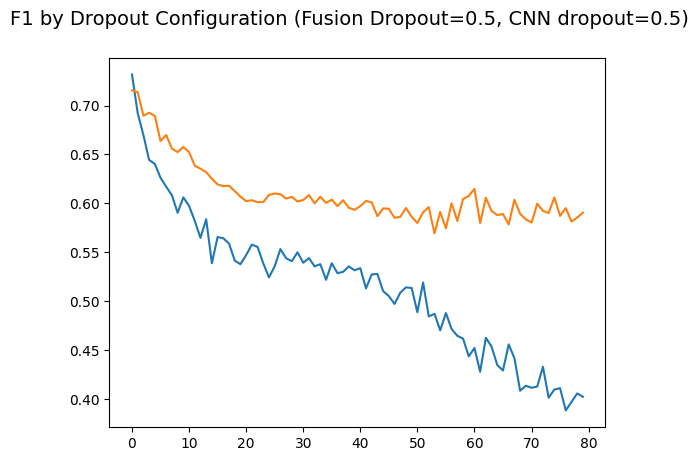

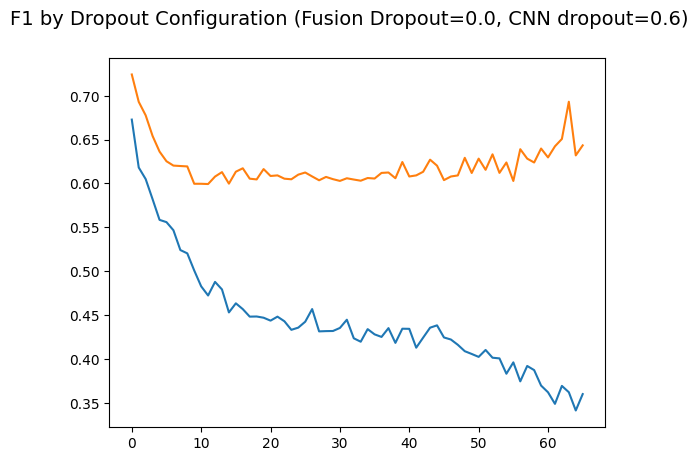

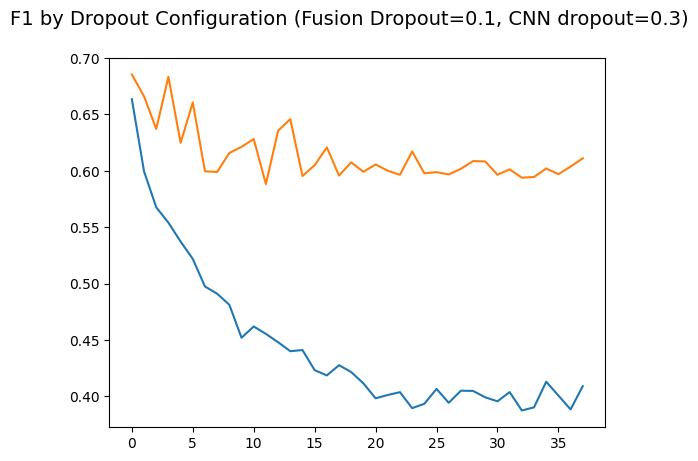

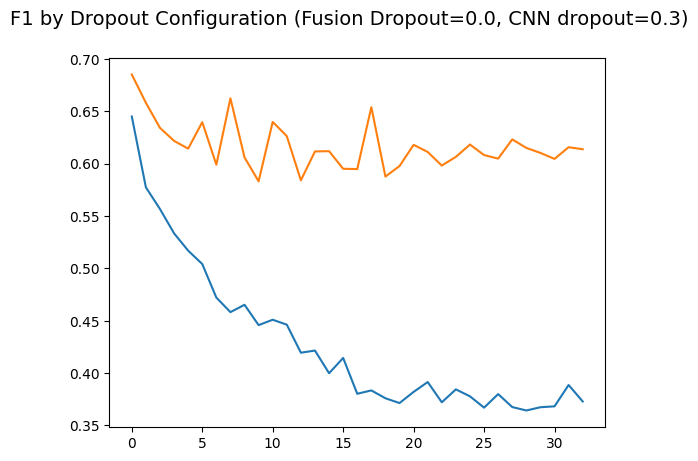

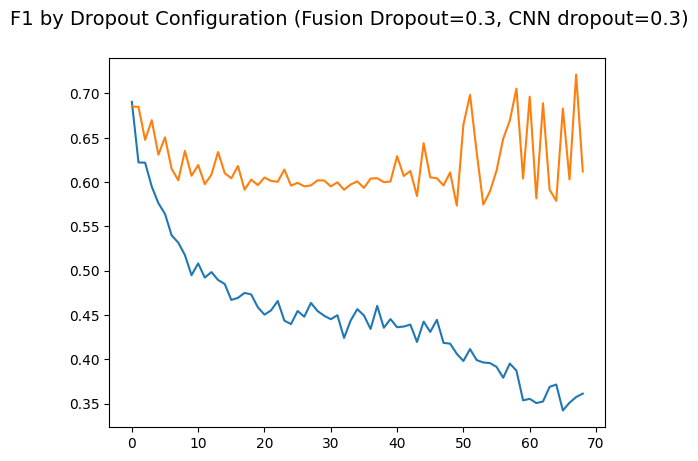

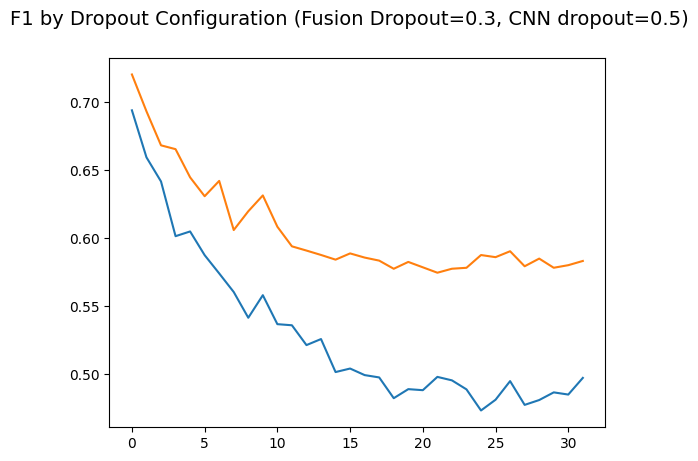

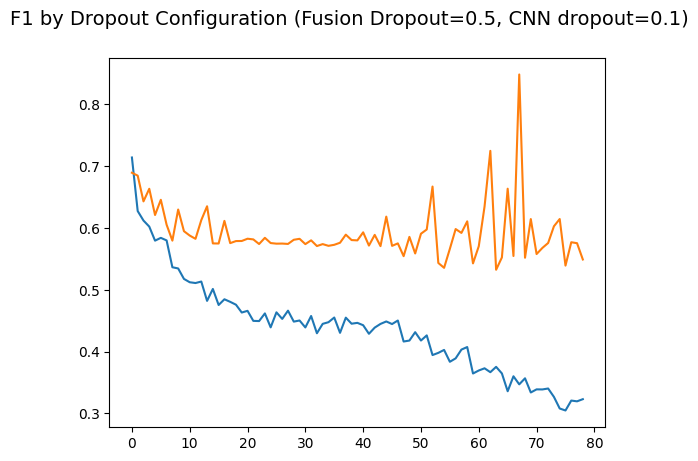

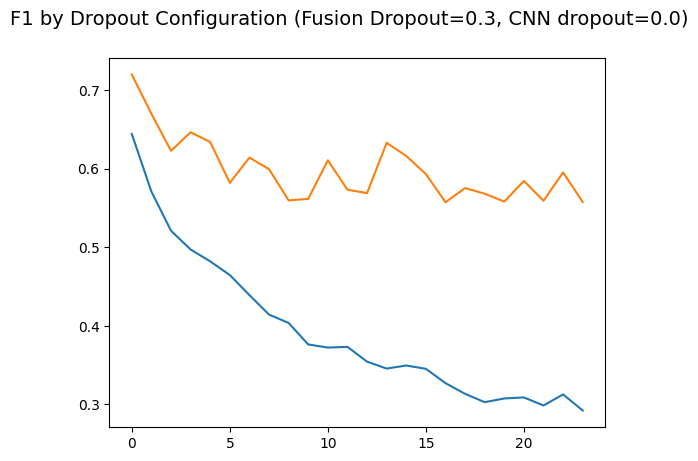

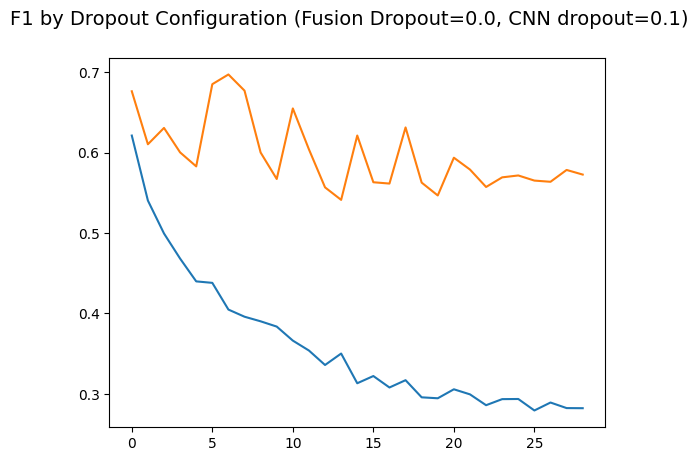

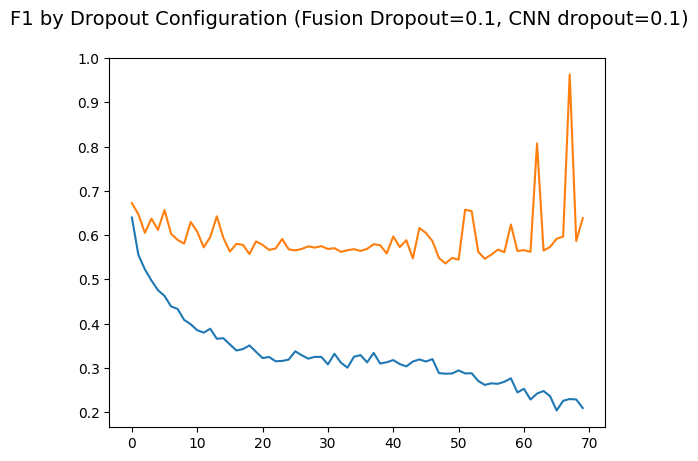

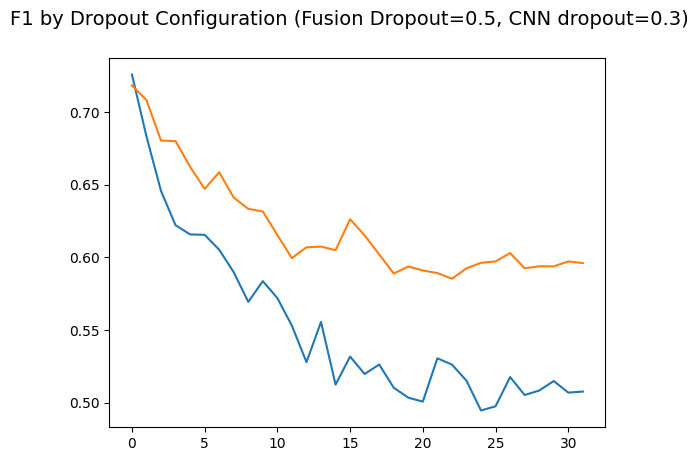

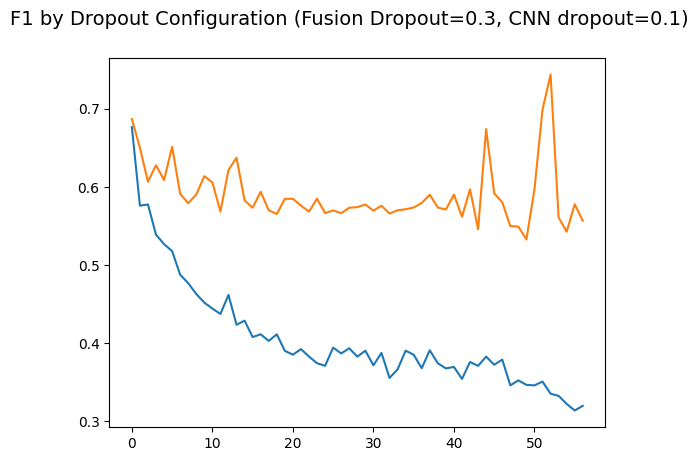

In [62]:
# Plotting train/val loss curves for all combos
allResultFiles = [f for f in os.listdir('Databases/ICBHI/traintest_CLEANED/Record_Crackles_Narrow_Wide') if f.endswith('.pkl')]

learning_rate = 0.0001
weight_decay = 0.03

for resultFile in allResultFiles:

    testResults = load_experiment_results(os.path.join(recordFolder,resultFile))

    if testResults['learning_rate'] != learning_rate or testResults['weight_decay'] != weight_decay:
        continue


    train_loss = testResults['training_history']['train_losses']
    val_loss = testResults['training_history']['val_losses']
    fus_dropout = testResults['dropout_fusion']
    cnn_dropout = testResults['dropout_cnn']
    fig,ax = plt.subplots()

    ax.plot(train_loss)
    ax.plot(val_loss)
    plt.suptitle(f'F1 by Dropout Configuration (Fusion Dropout={fus_dropout}, CNN dropout={cnn_dropout})', fontsize=14)

In [9]:
pip install openl3


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached protobuf-4.25.8-cp37-abi3-macosx_10_9_universal2.whl.metadata (541 bytes)
  Using cached tensorflow_io_gcs_filesystem-0.37.1-cp311-cp311-macosx_10_14_x86_64.whl.metadata (14 kB)
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
INFO: pip is still looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

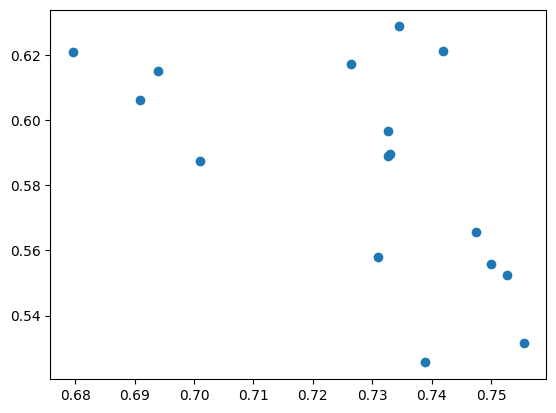

In [64]:
plt.scatter(df['val_f1'],df['best_val_loss'])

In [68]:
# analysing split of patient data in folds

datFilePath = 'Databases/ICBHI/traintest_CLEANED/'

datFile = 'cv_5_folds.pkl'

fullPath = os.path.join(datFilePath,datFile)

with open(fullPath,'rb') as f:
    sample = pickle.load(f,encoding='latin1')

In [80]:

countAK_train = np.zeros(5)
countLitt_train = np.zeros(5)
countMedi_train = np.zeros(5)

countAK_test = np.zeros(5)
countLitt_test = np.zeros(5)
countMedi_test = np.zeros(5)

for fold in range(0,5):
    filenames = sample[fold]['train_files']
    for filename in filenames:
        filename_components = filename.split('_')

        if filename_components[4].startswith('AKG'):
            countAK_train[fold] +=1
        elif filename_components[4].startswith('Litt'):
            countLitt_train[fold] +=1
        elif filename_components[4].startswith('Medi'):
            countMedi_train[fold] +=1
        else:
            print(filename)
    
    filenames = sample[fold]['test_files']
    for filename in filenames:
        filename_components = filename.split('_')

        if filename_components[4].startswith('AKG'):
            countAK_test[fold] +=1
        elif filename_components[4].startswith('Litt'):
            countLitt_test[fold] +=1
        elif filename_components[4].startswith('Medi'):
            countMedi_test[fold] +=1
        else:
            print(filename)
    

In [84]:
counts = {
    'AK_train': countAK_train,
    'Litt_train': countLitt_train,
    'Medi_train': countMedi_train,
    'AK_test': countAK_test,
    'Litt_test': countLitt_test,
    'Medi_test': countMedi_test
}


In [86]:
count_df = pd.DataFrame(counts)

In [87]:
count_df

,AK_train,Litt_train,Medi_train,AK_test,Litt_test,Medi_test
0,624.0,443.0,431.0,77.0,32.0,113.0
1,580.0,360.0,367.0,121.0,115.0,177.0
2,592.0,363.0,434.0,109.0,112.0,110.0
3,388.0,366.0,479.0,313.0,109.0,65.0
4,620.0,368.0,465.0,81.0,107.0,79.0


In [104]:
pct_df = count_df.copy()

pct_df['AK_train'] = count_df.apply(lambda x: 100*x['AK_train'] / (x['AK_train'] + x['Litt_train'] + x['Medi_train']),axis=1)
pct_df['Litt_train'] = count_df.apply(lambda x: 100*x['Litt_train'] / (x['AK_train'] + x['Litt_train'] + x['Medi_train']),axis=1)
pct_df['Medi_train'] = count_df.apply(lambda x: 100*x['Medi_train'] / (x['AK_train'] + x['Litt_train'] + x['Medi_train']),axis=1)

pct_df['AK_test'] = count_df.apply(lambda x: 100*x['AK_test'] / (x['AK_test'] + x['Litt_test'] + x['Medi_test']),axis=1)
pct_df['Litt_test'] = count_df.apply(lambda x: 100*x['Litt_test'] / (x['AK_test'] + x['Litt_test'] + x['Medi_test']),axis=1)
pct_df['Medi_test'] = count_df.apply(lambda x: 100*x['Medi_test'] / (x['AK_test'] + x['Litt_test'] + x['Medi_test']),axis=1)


In [105]:
pct_df

,AK_train,Litt_train,Medi_train,AK_test,Litt_test,Medi_test
0,41.655541,29.572764,28.771696,34.684685,14.414414,50.900901
1,44.376435,27.543994,28.079572,29.297821,27.845036,42.857143
2,42.620590,26.133909,31.245500,32.930514,33.836858,33.232628
3,31.467964,29.683698,38.848337,64.271047,22.381930,13.347023
4,42.670337,25.326910,32.002753,30.337079,40.074906,29.588015


In [103]:
443/(624+443+431)

0.29572763684913217

In [1]:
pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]2/3 [imblearn]d-learn]
Note: you may need to restart the kernel to use updated packages.


In [3]:
from RandomForest_ICBHI import RF_Config
import pickle
import os

with open(os.path.join(RF_Config.dir_testTrainData, 'train_val_test_split.pkl'), 'rb') as f:
    split_info = pickle.load(f)

In [4]:
split_info

{'train_files': ['104_1b1_Al_sc_Litt3200_0.dat',
  '104_1b1_Al_sc_Litt3200_1.dat',
  '104_1b1_Al_sc_Litt3200_2.dat',
  '104_1b1_Al_sc_Litt3200_3.dat',
  '104_1b1_Al_sc_Litt3200_4.dat',
  '104_1b1_Al_sc_Litt3200_5.dat',
  '104_1b1_Lr_sc_Litt3200_0.dat',
  '104_1b1_Lr_sc_Litt3200_1.dat',
  '104_1b1_Lr_sc_Litt3200_2.dat',
  '104_1b1_Lr_sc_Litt3200_3.dat',
  '104_1b1_Pl_sc_Litt3200_0.dat',
  '104_1b1_Pl_sc_Litt3200_1.dat',
  '104_1b1_Pl_sc_Litt3200_10.dat',
  '104_1b1_Pl_sc_Litt3200_2.dat',
  '104_1b1_Pl_sc_Litt3200_3.dat',
  '104_1b1_Pl_sc_Litt3200_4.dat',
  '104_1b1_Pl_sc_Litt3200_5.dat',
  '104_1b1_Pl_sc_Litt3200_6.dat',
  '104_1b1_Pl_sc_Litt3200_7.dat',
  '104_1b1_Pl_sc_Litt3200_8.dat',
  '104_1b1_Pl_sc_Litt3200_9.dat',
  '104_1b1_Pr_sc_Litt3200_0.dat',
  '104_1b1_Pr_sc_Litt3200_1.dat',
  '104_1b1_Pr_sc_Litt3200_2.dat',
  '104_1b1_Pr_sc_Litt3200_3.dat',
  '104_1b1_Pr_sc_Litt3200_4.dat',
  '104_1b1_Pr_sc_Litt3200_5.dat',
  '104_1b1_Pr_sc_Litt3200_6.dat',
  '104_1b1_Pr_sc_Litt3200_7.dat'

In [5]:
def data_Acq(fileName):
    file = open(fileName, 'rb')
    sample = pickle.load(file, encoding='latin1')
    file.close()
    return sample

preproc_dir = RF_Config.dir_preprocessed
files = split_info['train_files']

filename = files[0]
filepath = os.path.join(preproc_dir, filename)
    
# Load from pickle
sample = data_Acq(filepath)

In [7]:
files

['104_1b1_Al_sc_Litt3200_0.dat',
 '104_1b1_Al_sc_Litt3200_1.dat',
 '104_1b1_Al_sc_Litt3200_2.dat',
 '104_1b1_Al_sc_Litt3200_3.dat',
 '104_1b1_Al_sc_Litt3200_4.dat',
 '104_1b1_Al_sc_Litt3200_5.dat',
 '104_1b1_Lr_sc_Litt3200_0.dat',
 '104_1b1_Lr_sc_Litt3200_1.dat',
 '104_1b1_Lr_sc_Litt3200_2.dat',
 '104_1b1_Lr_sc_Litt3200_3.dat',
 '104_1b1_Pl_sc_Litt3200_0.dat',
 '104_1b1_Pl_sc_Litt3200_1.dat',
 '104_1b1_Pl_sc_Litt3200_10.dat',
 '104_1b1_Pl_sc_Litt3200_2.dat',
 '104_1b1_Pl_sc_Litt3200_3.dat',
 '104_1b1_Pl_sc_Litt3200_4.dat',
 '104_1b1_Pl_sc_Litt3200_5.dat',
 '104_1b1_Pl_sc_Litt3200_6.dat',
 '104_1b1_Pl_sc_Litt3200_7.dat',
 '104_1b1_Pl_sc_Litt3200_8.dat',
 '104_1b1_Pl_sc_Litt3200_9.dat',
 '104_1b1_Pr_sc_Litt3200_0.dat',
 '104_1b1_Pr_sc_Litt3200_1.dat',
 '104_1b1_Pr_sc_Litt3200_2.dat',
 '104_1b1_Pr_sc_Litt3200_3.dat',
 '104_1b1_Pr_sc_Litt3200_4.dat',
 '104_1b1_Pr_sc_Litt3200_5.dat',
 '104_1b1_Pr_sc_Litt3200_6.dat',
 '104_1b1_Pr_sc_Litt3200_7.dat',
 '104_1b1_Pr_sc_Litt3200_8.dat',
 '107_2b3

In [8]:
sample

{'signal': array([-7.08404963e-04, -6.28564435e-04, -4.15684066e-05, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]),
 'label': 0,
 'diagnosis': 3,
 'statistics_feature': array([ 0.09258424,  1.96190554, -0.9811755 , -0.17655761, -0.05876417,
         0.08614694, -0.70793117,  0.56275299, -0.22045356, -0.6551287 ,
         0.2182375 , -1.16632032, -1.28058625, -0.71732053,  0.12419866,
         0.01015298, -1.26246836, -0.90757337,  0.01543126,  1.67165558,
        -1.15992302,  2.43687574, -1.89994477,  0.52497945,  0.22778569,
        -0.38674131,  0.33249748,  0.95323874,  1.52254608, -1.74116957,
         0.31534688,  0.2669012 ,  1.10480145, -0.4719315 , -0.88563553,
         2.17116371,  1.02444079, -1.15467517,  0.07137405,  1.33156257,
         1.30125254, -0.9551703 ]),
 'statistics_feature_names': ['short_zcr_mean',
  'short_zcr_std',
  'short_rms_mean',
  'short_rms_std',
  'short_rms_max',
  'short_rms_kurtosis',
  'short_flux_mean',
  'short_flux_std',
  '